📦 Columns: ['id', 'text', 'timestamp', 'platform', 'user', 'ห้องพัก', 'บริการ', 'สถานที่ตั้ง']
   id                                               text   timestamp  \
0   1  Air conditioning worked well and quietly. Room...  2025-04-18   
1   2  Check-in was quick and professional. Fitness r...  2025-08-31   

      platform    user  ห้องพัก  บริการ  สถานที่ตั้ง  
0  Google Maps   Priya        4       4            4  
1  Google Maps  Daniel        4       2            1   


📊 Feature Importance (รวมข้อความเป็นก้อน):
        Feature  Importance  Importance %
0       ห้องพัก    0.405194     40.519416
1        บริการ    0.279153     27.915272
2   สถานที่ตั้ง    0.255835     25.583466
3  ข้อความรีวิว    0.059818      5.981846
4      Platform    0.000000      0.000000


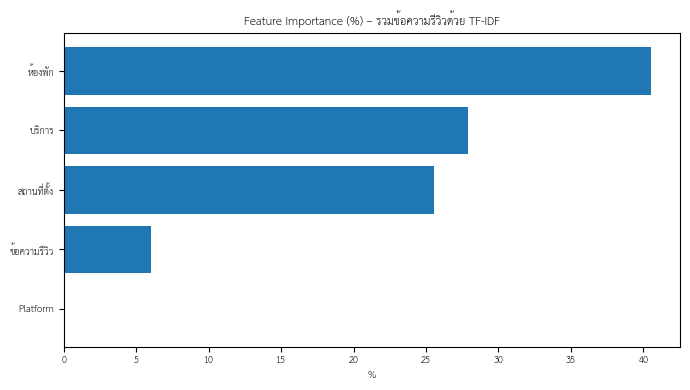


💾 Saved files:
 - feature_importance_summary.csv
 - feature_importance_plot.png
 - sentiment_analysis_results.csv
 - decision_tree_plot.png


In [10]:
# ================== Jazz Hotel Penang – Text + Numeric Features ==================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from matplotlib import font_manager
font_path = '/content/THSarabunNew.ttf'
font_manager.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'TH Sarabun New'

# ---------- 1) โหลดไฟล์ (ลองหลายชื่อ) ----------
df = pd.read_csv("/content/reviwe.csv")

print("📦 Columns:", df.columns.tolist())
print(df.head(2), "\n")

# ---------- 2) ตรวจคอลัมน์สำคัญ ----------
required_cols = ['text', 'ห้องพัก', 'บริการ', 'สถานที่ตั้ง']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f"❌ ขาดคอลัมน์จำเป็น: {missing} (ต้องมี text, ห้องพัก, บริการ, สถานที่ตั้ง)")

# ถ้ายังไม่มี 'คะแนน' ให้สร้างจากค่าเฉลี่ย 3 ด้าน
if 'คะแนน' not in df.columns:
    df['คะแนน'] = df[['ห้องพัก', 'บริการ', 'สถานที่ตั้ง']].mean(axis=1).round(2)

# ถ้าไม่มี platform ก็สร้างให้เป็นค่าเดียว (จะได้ไม่ล้ม)
if 'platform' not in df.columns:
    df['platform'] = 'Google Maps'

# ---------- 3) เตรียมฟีเจอร์ ----------
text_feature = 'text'
numeric_features = ['บริการ', 'ห้องพัก', 'สถานที่ตั้ง']
categorical_features = ['platform']
target = 'คะแนน'

# TF-IDF รองรับภาษาไทย + อังกฤษ (กำหนด token_pattern จับอักษรไทยได้)
tfidf = TfidfVectorizer(
    max_features=500,
    token_pattern=r'(?u)\b[\wก-๙]{2,}\b',  # จับไทย/อังกฤษ ตั้งแต่ 2 ตัวอักษรขึ้นไป
    lowercase=True
)

preprocess = ColumnTransformer(
    transformers=[
        ('text', tfidf, text_feature),
        ('num', 'passthrough', numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# ---------- 4) โมเดล ----------
reg = DecisionTreeRegressor(max_depth=8, random_state=42)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', reg)
])

# ---------- 5) แบ่ง train/test + เทรน ----------
X = df[[text_feature] + numeric_features + categorical_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model.fit(X_train, y_train)

# ---------- 6) ประเมิน ----------
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # แทน squared=False (กันปัญหา sklearn เวอร์ชันเก่า)


# ---------- 7) Feature Importance (รวมข้อความ + รวม Platform) ----------
# ชื่อฟีเจอร์แต่ละบล็อกหลังแปลง
tfidf_names = model.named_steps['preprocess'].named_transformers_['text'].get_feature_names_out()
ohe = model.named_steps['preprocess'].named_transformers_['cat']
ohe_names = list(ohe.get_feature_names_out(categorical_features))

all_names = list(tfidf_names) + numeric_features + ohe_names
importances = model.named_steps['regressor'].feature_importances_

# sum ก้อนข้อความ
text_len = len(tfidf_names)
num_len = len(numeric_features)
cat_len = len(ohe_names)

text_imp = importances[:text_len].sum()
num_imps = importances[text_len:text_len+num_len]
cat_imps = importances[text_len+num_len:]

platform_imp = float(cat_imps.sum())

rows = [
    ['ข้อความรีวิว', text_imp],
]

for n, imp in zip(numeric_features, num_imps):
    rows.append([n, float(imp)])
rows.append(['Platform', platform_imp])


imp_df = pd.DataFrame(rows, columns=['Feature', 'Importance'])
imp_df['Importance %'] = imp_df['Importance'] / imp_df['Importance'].sum() * 100
imp_df = imp_df.sort_values('Importance %', ascending=False).reset_index(drop=True)

print("\n📊 Feature Importance (รวมข้อความเป็นก้อน):")
print(imp_df)

# ---------- 8) วาดกราฟและบันทึก ----------
plt.figure(figsize=(7,4))
plt.barh(imp_df['Feature'], imp_df['Importance %'])
plt.gca().invert_yaxis()
plt.title('Feature Importance (%) – รวมข้อความรีวิวด้วย TF-IDF')
plt.xlabel('%')
plt.tight_layout()
plt.savefig('feature_importance_plot.png', dpi=140)
plt.show()

imp_df.to_csv('feature_importance_summary.csv', index=False, encoding='utf-8')
df.to_csv("sentiment_analysis_results.csv", index=False)

plt.figure(figsize=(18, 8))
plot_tree(
    model.named_steps["regressor"],   # pipeline ของคุณใช้ชื่อ regressor
    feature_names=all_names,
    filled=True,
    fontsize=6,
    rounded=True
)
plt.title("Decision Tree Structure (Jazz Hotel Penang)")
plt.savefig("decision_tree_plot.png", bbox_inches='tight', dpi=150)
plt.close()

print("\n💾 Saved files:")
print(" - feature_importance_summary.csv")
print(" - feature_importance_plot.png")
print(" - sentiment_analysis_results.csv")
print(" - decision_tree_plot.png")

